<a href="https://colab.research.google.com/github/kuNalsharma0725/Capstone-Project--AI_ML/blob/main/Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
# 1.Load the dataset
url='https://raw.githubusercontent.com/kuNalsharma0725/Capstone-Project--AI_ML/refs/heads/main/student_habits_performance.csv'
df=pd.read_csv(url)

In [74]:
df.head() #print first five rows

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [75]:
df.dtypes #column data types

,0
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object


In [76]:
df.shape #dataframe shape

(1000, 16)

In [77]:
# 2.Null value analysis
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [78]:
# Only parental_education_level contain the null values

In [79]:
(df.isnull().sum() / df.shape[0]) * 100 #Finding null percentage

,0
student_id,0.0
age,0.0
gender,0.0
study_hours_per_day,0.0
social_media_hours,0.0
netflix_hours,0.0
part_time_job,0.0
attendance_percentage,0.0
sleep_hours,0.0
diet_quality,0.0


* No column exceed a 20% null rate.
* And no numneric column contain null values.
* Only one categorical column "parental_education_level" contain null values.






In [80]:
# Fill the missing values
df['parental_education_level'] = df['parental_education_level'].fillna('Unknown')

In [81]:
df.isnull().sum() #again check null values

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [82]:
# 3. Duplicate detection and removal
df.duplicated().sum()

np.int64(0)

There is no duplicated rows in the given dataset.


In [83]:
# 4.Data type correction
print(df.dtypes)
before=df.memory_usage(deep=True).sum()
print(f'Before {before} bytes')

student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64
dtype: object
Before 447593 bytes


Upon inspecting the dataset's dtypes using df.dtypes, all numeric columns were already correctly inferred as int64/float64, so no dtype correction is necessary for this dataset.

In [84]:
df['diet_quality'] = df['diet_quality'].astype('category') #Convert string column to category dtype

In [85]:
print(df.dtypes)
after=df.memory_usage(deep=True).sum()
print(f'after {after} bytes')

student_id                         object
age                                 int64
gender                             object
study_hours_per_day               float64
social_media_hours                float64
netflix_hours                     float64
part_time_job                      object
attendance_percentage             float64
sleep_hours                       float64
diet_quality                     category
exercise_frequency                  int64
parental_education_level           object
internet_quality                   object
mental_health_rating                int64
extracurricular_participation      object
exam_score                        float64
dtype: object
after 395860 bytes


In [86]:
print(f'There a difference of {before-after} bytes of memory usage before and after the conversion using.')

There a difference of 51733 bytes of memory usage before and after the conversion using.


In [87]:
# 5.Descriptive statistics and skewness
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [88]:
# Initialize variables to keep track of the highest absolute skewness
highest_skew_col = None
highest_skew_value = 0
# Loop through only the numerical columns in the DataFrame to check swekness
for col in df.select_dtypes(include=['number']).columns:
    skew_value = df[col].skew()
    print(f"Column '{col}' Skewness: {skew_value:.4f}")
    if abs(skew_value) > highest_skew_value:
      highest_skew_value = abs(skew_value)
      highest_skew_col = col


Column 'age' Skewness: 0.0084
Column 'study_hours_per_day' Skewness: 0.0543
Column 'social_media_hours' Skewness: 0.1198
Column 'netflix_hours' Skewness: 0.2372
Column 'attendance_percentage' Skewness: -0.2378
Column 'sleep_hours' Skewness: 0.0915
Column 'exercise_frequency' Skewness: -0.0319
Column 'mental_health_rating' Skewness: 0.0378
Column 'exam_score' Skewness: -0.1564


In [89]:
# print higest absolute skewness
print(f" Highest Absolute Skewness: '{highest_skew_col}' ({highest_skew_value:.4f})")

 Highest Absolute Skewness: 'attendance_percentage' (0.2378)


In [90]:
#6. Outlier detection with IQR
def detect_outliers_iqr(df, col):
    Q1 = df['age'].quantile(0.25)
    Q3 = df['age'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]

    print(f"Column: {col}")
    print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Outliers found: {outliers.shape[0]}\n")

    return outliers

# Usage
outliers_price = detect_outliers_iqr(df, 'age')

Column: age
Q1: 18.75, Q3: 23.0, IQR: 4.25
Lower Bound: 12.375, Upper Bound: 29.375
Outliers found: 0



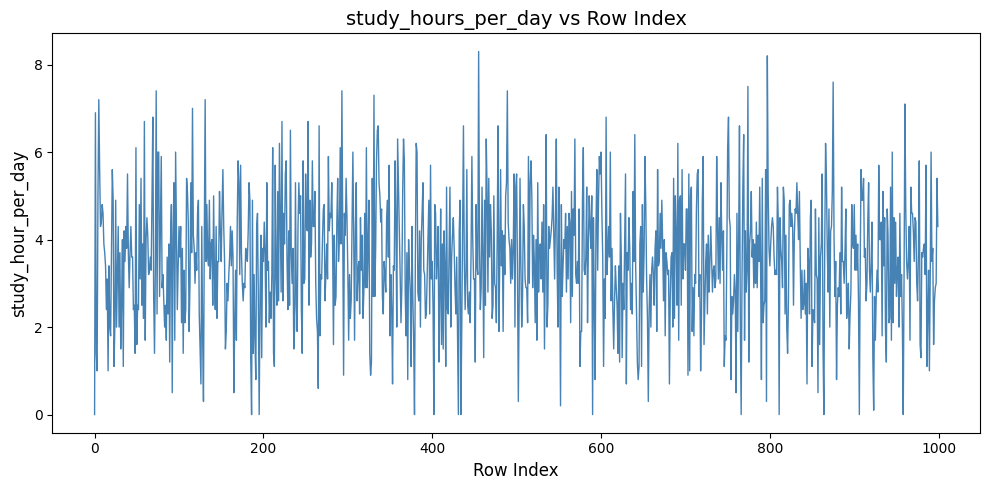

In [91]:
#7. Visualizations
# Line plot between study_hour_per_day and row index

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['study_hours_per_day'], color='steelblue', linewidth=1)

plt.title('study_hours_per_day vs Row Index', fontsize=14)
plt.xlabel('Row Index', fontsize=12)
plt.ylabel('study_hour_per_day', fontsize=12)

plt.tight_layout()
plt.show()

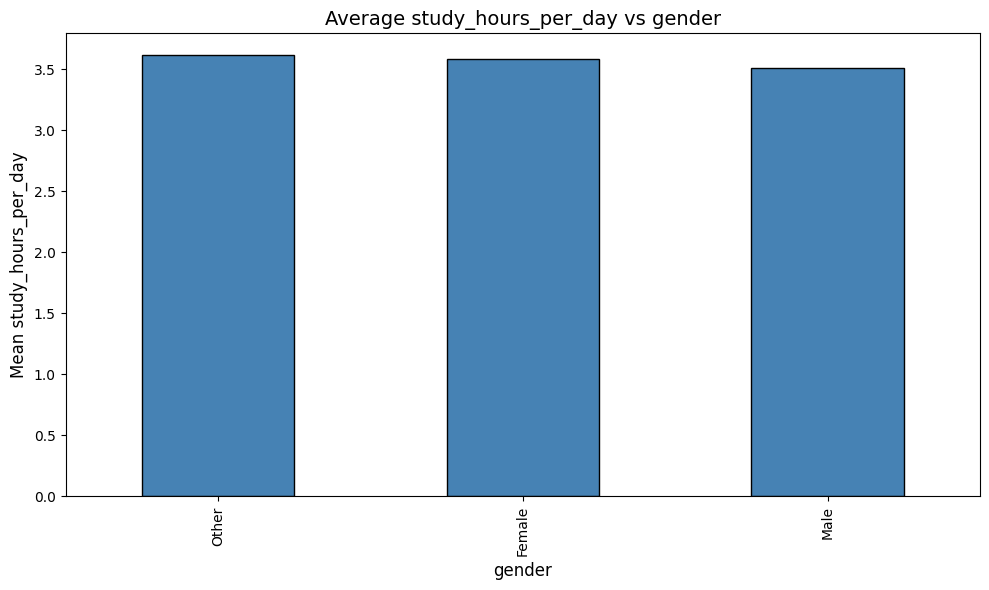

In [92]:
# bar chart between gender and study_hour_per_day
cat_col = 'gender'
num_col = 'study_hours_per_day'

grouped = df.groupby(cat_col)[num_col].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
grouped.plot.bar(color='steelblue', edgecolor='black')

plt.title(f'Average {num_col} vs {cat_col}', fontsize=14)
plt.xlabel(cat_col, fontsize=12)
plt.ylabel(f'Mean {num_col}', fontsize=12)
plt.tight_layout()
plt.show()

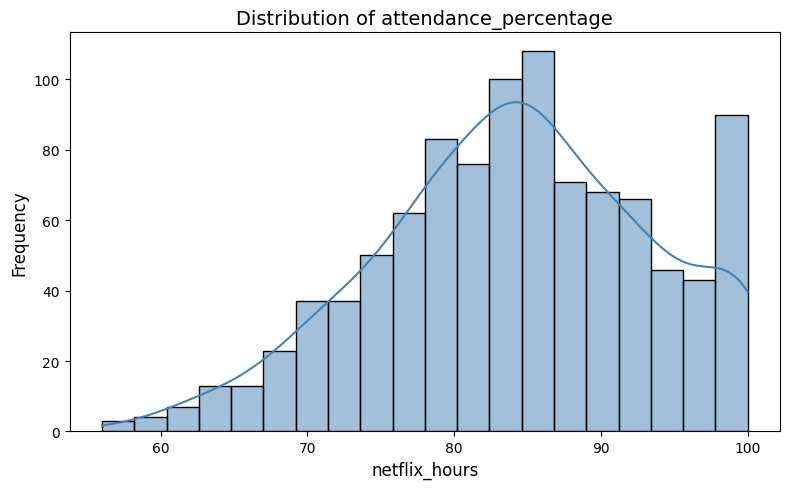

In [93]:
#histogram of higest skewed numeric column
plt.figure(figsize=(8, 5))
sns.histplot(df['attendance_percentage'], bins=20, kde=True, color='steelblue')

plt.title('Distribution of attendance_percentage', fontsize=14)
plt.xlabel('netflix_hours', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

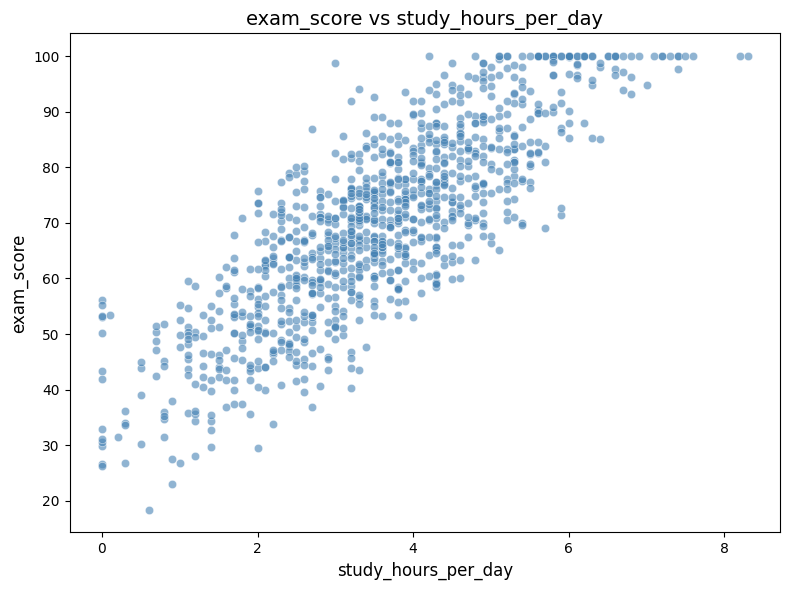

In [94]:
#scatter plot of two numeric column
col_x='study_hours_per_day'
col_y='exam_score'

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x=col_x, y=col_y, color='steelblue', alpha=0.6)

plt.title(f'{col_y} vs {col_x}', fontsize=14)
plt.xlabel(col_x, fontsize=12)
plt.ylabel(col_y, fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_647/407079850.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=num_col, palette='Set2')


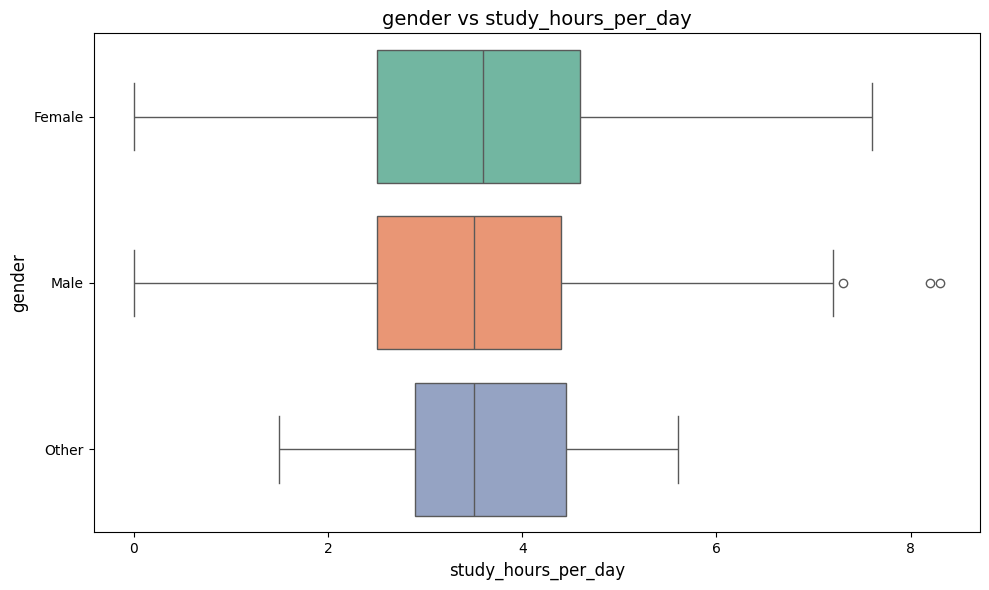

In [95]:
#box plot
cat_col = 'study_hours_per_day'
num_col = 'gender'

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=cat_col, y=num_col, palette='Set2')

plt.title(f'{num_col} vs {cat_col}', fontsize=14)
plt.xlabel(cat_col, fontsize=12)
plt.ylabel(num_col, fontsize=12)

plt.tight_layout()
plt.show()

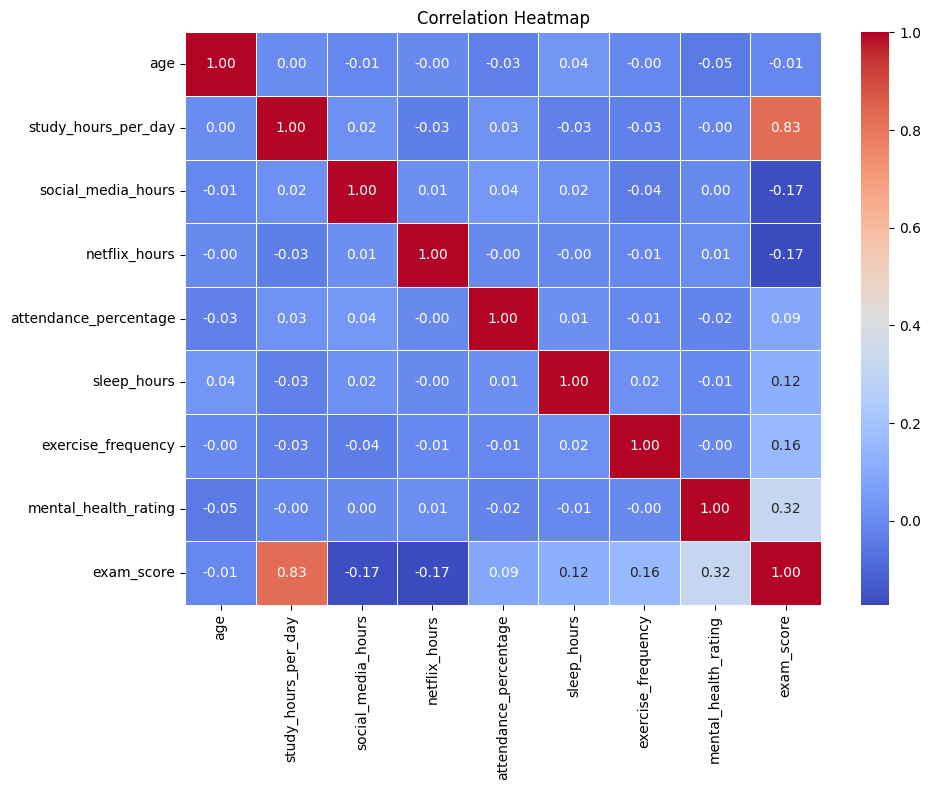

In [96]:
# 8. Correlation heat map
numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Study_hours_per_day and exam_score has the highest absolute correlation.

In [97]:
# 9(a). Imputation strategy comparison
# Compute mean and median
def compute_mean_median(df, col):
    mean_val = df[col].mean()
    median_val = df[col].median()


    print(f"Column: {col}")
    print(f"  Mean     : {mean_val:.2f}")
    print(f"  Median   : {median_val:.2f}")

In [98]:
# mean and median for netflix_hours
compute_mean_median(df, 'netflix_hours')

Column: netflix_hours
  Mean     : 1.82
  Median   : 1.80


In [99]:
# mean and median for attendance_percentage
compute_mean_median(df, 'attendance_percentage')

Column: attendance_percentage
  Mean     : 84.13
  Median   : 84.40


In [100]:
#9(b). Spearman rank correlation
spearman=numeric_df.corr(method='spearman')
spearman

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.001736,-0.011916,0.001955,-0.023451,0.038537,-0.003872,-0.045544,-0.010017
study_hours_per_day,0.001736,1.000000,0.021456,-0.035914,0.024556,-0.030694,-0.038334,-0.008743,0.812078
social_media_hours,-0.011916,0.021456,1.000000,0.011746,0.046354,0.015078,-0.033821,-0.004122,-0.166259
netflix_hours,0.001955,-0.035914,0.011746,1.000000,-0.002176,-0.015961,-0.007641,0.002608,-0.165195
attendance_percentage,-0.023451,0.024556,0.046354,-0.002176,1.000000,0.012027,-0.009074,-0.007892,0.093898
sleep_hours,0.038537,-0.030694,0.015078,-0.015961,0.012027,1.000000,0.018790,-0.005198,0.123396
exercise_frequency,-0.003872,-0.038334,-0.033821,-0.007641,-0.009074,0.018790,1.000000,-0.000215,0.150205
mental_health_rating,-0.045544,-0.008743,-0.004122,0.002608,-0.007892,-0.005198,-0.000215,1.000000,0.323364
exam_score,-0.010017,0.812078,-0.166259,-0.165195,0.093898,0.123396,0.150205,0.323364,1.000000


In [101]:
#difference table showing |Spearman − Pearson| for each pair
diff_mat = (spearman - correlation_matrix).abs()
diff_mat

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,0.000000,0.002236,0.002764,0.003129,0.002605,0.001055,0.000036,0.000443,0.001110
study_hours_per_day,0.002236,0.000000,0.001174,0.004755,0.001708,0.002937,0.009633,0.004975,0.013341
social_media_hours,0.002764,0.001174,0.000000,0.000269,0.005875,0.003158,0.003498,0.005618,0.000474
netflix_hours,0.003129,0.004755,0.000269,0.000000,0.000084,0.015027,0.001193,0.005427,0.006584
attendance_percentage,0.002605,0.001708,0.005875,0.000084,0.000000,0.001729,0.001217,0.010853,0.004063
sleep_hours,0.001055,0.002937,0.003158,0.015027,0.001729,0.000000,0.000979,0.001310,0.001713
exercise_frequency,0.000036,0.009633,0.003498,0.001193,0.001217,0.000979,0.000000,0.000028,0.009902
mental_health_rating,0.000443,0.004975,0.005618,0.005427,0.010853,0.001310,0.000028,0.000000,0.001841
exam_score,0.001110,0.013341,0.000474,0.006584,0.004063,0.001713,0.009902,0.001841,0.000000


In [102]:
#highest absolute difference
highest_col = diff_mat.max().idxmax()
highest_col

'netflix_hours'

In [103]:
#Grouped aggregation
df.groupby('gender')['study_hours_per_day'].agg(['mean', 'std', 'count'])

,mean,std,count
gender,,,
Female,3.583784,1.489444,481
Male,3.510692,1.482273,477
Other,3.611905,1.028189,42


In [104]:
#10.Save the clean dataset
df.to_csv('cleaned_data.csv', index=False)

In [105]:
from google.colab import files
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>